<a href="https://colab.research.google.com/github/jyotipant614-cloud/AI_Resume_Analyser/blob/main/food_delivery_by_naive_%2C_KNN_%2C_DT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Food_Delivery_Time_Prediction.csv to Food_Delivery_Time_Prediction.csv


In [ ]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (200, 15)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [ ]:
print(df.columns.tolist())

['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance', 'Weather_Conditions', 'Traffic_Conditions', 'Delivery_Person_Experience', 'Order_Priority', 'Order_Time', 'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
Order_ID,0.0
Customer_Location,0.0
Restaurant_Location,0.0
Distance,0.0
Weather_Conditions,0.0
Traffic_Conditions,0.0
Delivery_Person_Experience,0.0
Order_Priority,0.0
Order_Time,0.0
Vehicle_Type,0.0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['order_id', 'customer_location', 'restaurant_location', 'distance', 'weather_conditions', 'traffic_conditions', 'delivery_person_experience', 'order_priority', 'order_time', 'vehicle_type', 'restaurant_rating', 'customer_rating', 'delivery_time', 'order_cost', 'tip_amount']


In [ ]:
df.head()

,order_id,customer_location,restaurant_location,distance,weather_conditions,traffic_conditions,delivery_person_experience,order_priority,order_time,vehicle_type,restaurant_rating,customer_rating,delivery_time,order_cost,tip_amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [ ]:
df.describe()

,distance,delivery_person_experience,restaurant_rating,customer_rating,delivery_time,order_cost,tip_amount
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,11.498050,5.250000,3.738500,3.686500,70.494950,1046.488700,46.616650
std,6.841755,2.745027,0.703021,0.697063,29.830694,548.568922,29.361706
min,0.520000,1.000000,2.500000,2.600000,15.230000,122.300000,1.240000
25%,6.090000,3.000000,3.200000,3.100000,46.997500,553.270000,21.602500
50%,10.265000,5.000000,3.800000,3.700000,72.775000,1035.950000,47.530000
75%,16.497500,8.000000,4.300000,4.300000,96.650000,1543.125000,70.245000
max,24.900000,10.000000,5.000000,5.000000,119.670000,1997.420000,99.740000


In [ ]:
print(df["weather_conditions"].value_counts())

weather_conditions
Rainy     57
Sunny     53
Snowy     48
Cloudy    42
Name: count, dtype: int64


In [ ]:
print(df["traffic_conditions"].value_counts())

traffic_conditions
Low       81
Medium    68
High      51
Name: count, dtype: int64


In [ ]:
print(df["vehicle_type"].value_counts())

vehicle_type
Bike       69
Bicycle    69
Car        62
Name: count, dtype: int64


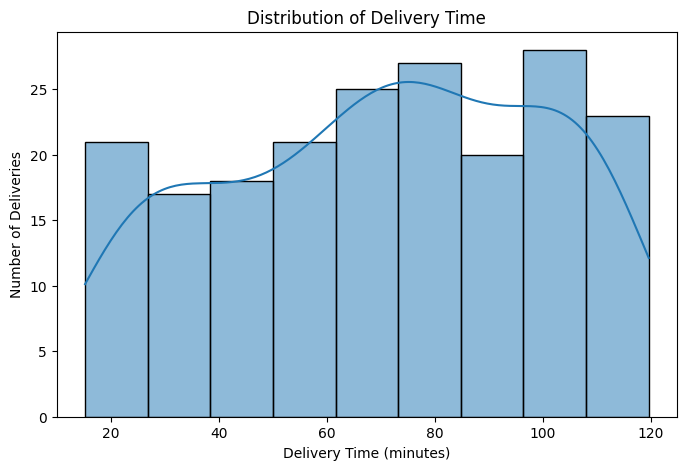

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["delivery_time"],
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Deliveries")

plt.show()

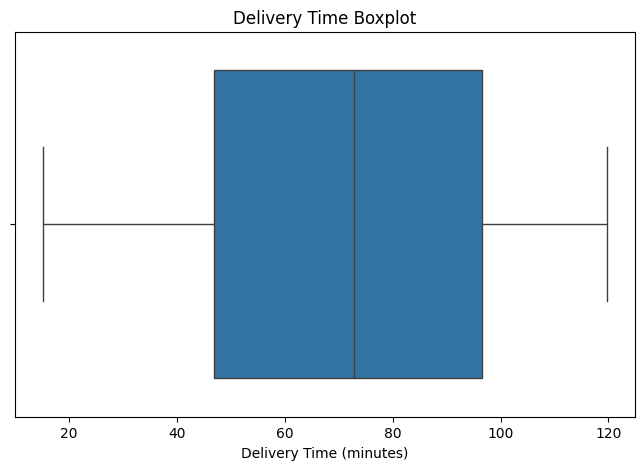

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["delivery_time"]
)

plt.title("Delivery Time Boxplot")
plt.xlabel("Delivery Time (minutes)")

plt.show()

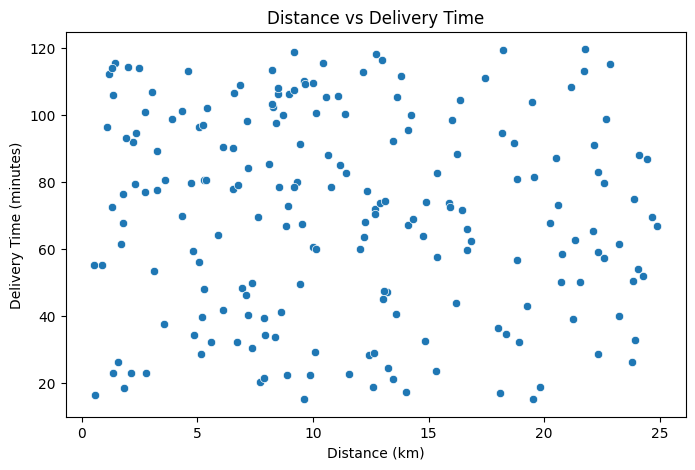

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="distance",
    y="delivery_time"
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.show()

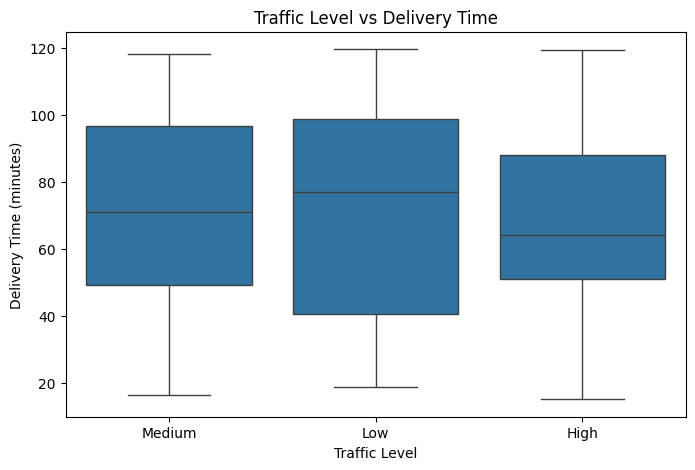

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="traffic_conditions",
    y="delivery_time"
)

plt.title("Traffic Level vs Delivery Time")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (minutes)")

plt.show()

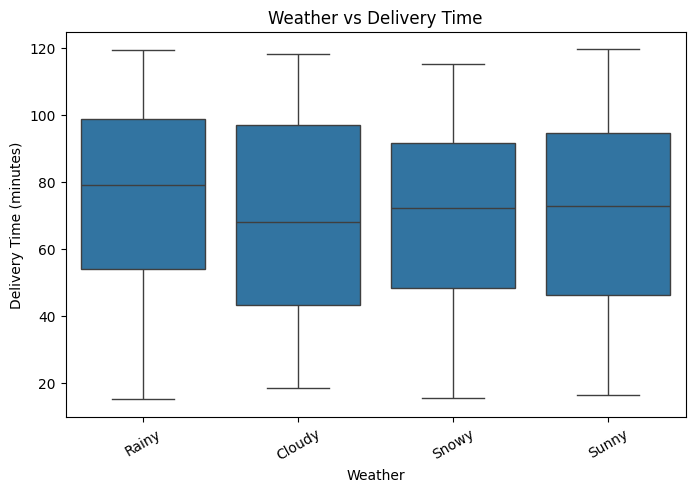

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="weather_conditions",
    y="delivery_time"
)

plt.title("Weather vs Delivery Time")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (minutes)")

plt.xticks(rotation=30)

plt.show()

In [ ]:
median_delivery_time = df["delivery_time"].median()

print("Median delivery time:", median_delivery_time)

Median delivery time: 72.775


In [ ]:
df["delivery_status"] = np.where(
    df["delivery_time"] > median_delivery_time,
    1,
    0
)

In [ ]:
df["delivery_status_label"] = df["delivery_status"].map({
    0: "Fast",
    1: "Delayed"
})

df[["delivery_time", "delivery_status", "delivery_status_label"]].head(10)

,delivery_time,delivery_status,delivery_status_label
0,26.22,0,Fast
1,62.61,0,Fast
2,48.43,0,Fast
3,111.63,1,Delayed
4,32.38,0,Fast
5,60.72,0,Fast
6,28.76,0,Fast
7,57.28,0,Fast
8,47.22,0,Fast
9,81.55,1,Delayed


In [ ]:
print(df["delivery_status_label"].value_counts())

delivery_status_label
Fast       100
Delayed    100
Name: count, dtype: int64


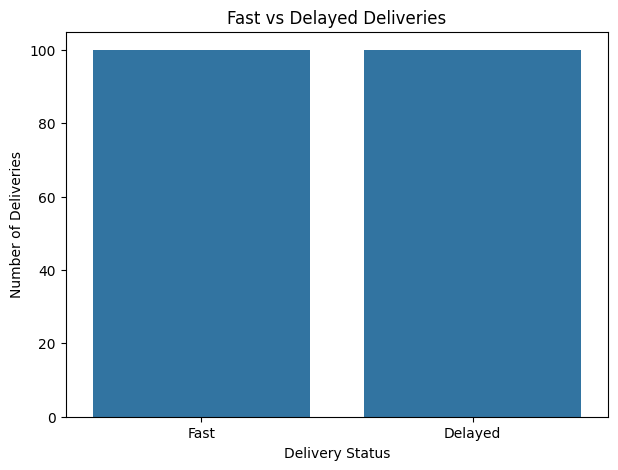

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="delivery_status_label"
)

plt.title("Fast vs Delayed Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")

plt.show()

In [ ]:
print(df.isnull().sum())

order_id                      0
customer_location             0
restaurant_location           0
distance                      0
weather_conditions            0
traffic_conditions            0
delivery_person_experience    0
order_priority                0
order_time                    0
vehicle_type                  0
restaurant_rating             0
customer_rating               0
delivery_time                 0
order_cost                    0
tip_amount                    0
delivery_status               0
delivery_status_label         0
dtype: int64


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [ ]:
print(df.isnull().sum())

order_id                      0
customer_location             0
restaurant_location           0
distance                      0
weather_conditions            0
traffic_conditions            0
delivery_person_experience    0
order_priority                0
order_time                    0
vehicle_type                  0
restaurant_rating             0
customer_rating               0
delivery_time                 0
order_cost                    0
tip_amount                    0
delivery_status               0
delivery_status_label         0
dtype: int64


In [ ]:
features = [
    "distance_km",
    "weather",
    "traffic_level",
    "time_of_day",
    "vehicle_type",
    "preparation_time_min",
    "courier_experience_yrs"
]

In [ ]:
print(df.columns.tolist())


['order_id', 'customer_location', 'restaurant_location', 'distance', 'weather_conditions', 'traffic_conditions', 'delivery_person_experience', 'order_priority', 'order_time', 'vehicle_type', 'restaurant_rating', 'customer_rating', 'delivery_time', 'order_cost', 'tip_amount', 'delivery_status', 'delivery_status_label']


In [ ]:
X = features
y = df["delivery_status"]

In [ ]:
print(type(X))

<class 'list'>


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

print(df.columns.tolist())
print(df.shape)

['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance', 'Weather_Conditions', 'Traffic_Conditions', 'Delivery_Person_Experience', 'Order_Priority', 'Order_Time', 'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']
(200, 15)


In [ ]:
median_delivery_time = df["Delivery_Time"].median()

df["delivery_status"] = np.where(
    df["Delivery_Time"] > median_delivery_time,
    1,
    0
)

print("Median delivery time:", median_delivery_time)
print(df["delivery_status"].value_counts())

Median delivery time: 72.775
delivery_status
0    100
1    100
Name: count, dtype: int64


In [ ]:
features = [
    "Distance",
    "Weather_Conditions",
    "Traffic_Conditions",
    "Delivery_Person_Experience",
    "Order_Priority",
    "Order_Time",
    "Vehicle_Type",
    "Restaurant_Rating",
    "Customer_Rating",
    "Order_Cost",
    "Tip_Amount"
]

X = df[features].copy()
y = df["delivery_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (200, 11)
y shape: (200,)


,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount
0,1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,1321.10,81.54
1,21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,152.21,29.02
2,6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,1644.38,64.17
3,13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,541.25,79.23
4,6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,619.81,2.34


In [ ]:

categorical_columns = X.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type']


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

print("Label encoding completed!")
X.head()

Label encoding completed!


,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount
0,1.57,1,2,4,2,0,2,4.1,3.0,1321.10,81.54
1,21.32,0,2,8,1,3,2,4.5,4.2,152.21,29.02
2,6.95,2,2,9,0,3,1,3.3,3.4,1644.38,64.17
3,13.79,0,1,2,2,1,1,3.2,3.7,541.25,79.23
4,6.72,1,0,6,1,3,1,3.5,2.8,619.81,2.34


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 11)
Testing data: (40, 11)


In [ ]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
nb_model = GaussianNB()

In [ ]:
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
nb_pred = nb_model.predict(X_test_scaled)

In [ ]:
print(nb_pred[:20])

[0 0 1 0 1 1 0 0 0 0 1 1 0 0 1 1 0 1 0 1]


In [ ]:
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.4


In [ ]:
nb_precision = precision_score(
    y_test,
    nb_pred,
    zero_division=0
)

print("Naive Bayes Precision:", nb_precision)

Naive Bayes Precision: 0.4


In [ ]:
nb_recall = recall_score(
    y_test,
    nb_pred,
    zero_division=0
)

print("Naive Bayes Recall:", nb_recall)

Naive Bayes Recall: 0.4


In [ ]:
nb_f1 = f1_score(
    y_test,
    nb_pred,
    zero_division=0
)

print("Naive Bayes F1-score:", nb_f1)

Naive Bayes F1-score: 0.4


In [ ]:
print(
    classification_report(
        y_test,
        nb_pred,
        target_names=["Fast", "Delayed"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Fast       0.40      0.40      0.40        20
     Delayed       0.40      0.40      0.40        20

    accuracy                           0.40        40
   macro avg       0.40      0.40      0.40        40
weighted avg       0.40      0.40      0.40        40



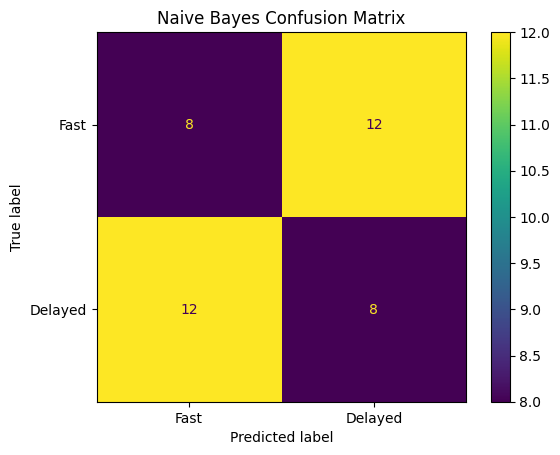

In [ ]:
cm_nb = confusion_matrix(y_test, nb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Fast", "Delayed"]
)

disp.plot()

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    accuracy_scores.append(scores.mean())

best_k = k_values[np.argmax(accuracy_scores)]

print("Best K:", best_k)
print("Best Cross-Validation Accuracy:", max(accuracy_scores))

Best K: 11
Best Cross-Validation Accuracy: 0.5625


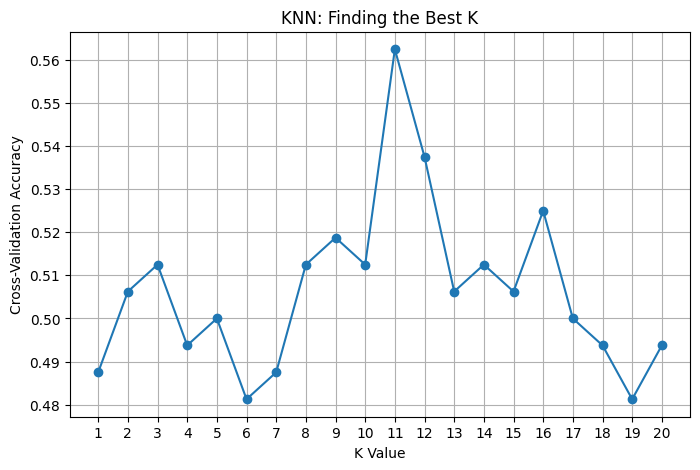

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracy_scores,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Cross-Validation Accuracy")
plt.title("KNN: Finding the Best K")
plt.xticks(k_values)
plt.grid()
plt.show()

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN model trained successfully!")

KNN model trained successfully!


In [ ]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("KNN Results")
print("-------------------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN Results
-------------------
Accuracy : 0.35
Precision: 0.36363636363636365
Recall   : 0.4
F1 Score : 0.38095238095238093


In [ ]:
print(classification_report(
    y_test,
    knn_pred,
    target_names=["Fast", "Delayed"]
))

              precision    recall  f1-score   support

        Fast       0.33      0.30      0.32        20
     Delayed       0.36      0.40      0.38        20

    accuracy                           0.35        40
   macro avg       0.35      0.35      0.35        40
weighted avg       0.35      0.35      0.35        40



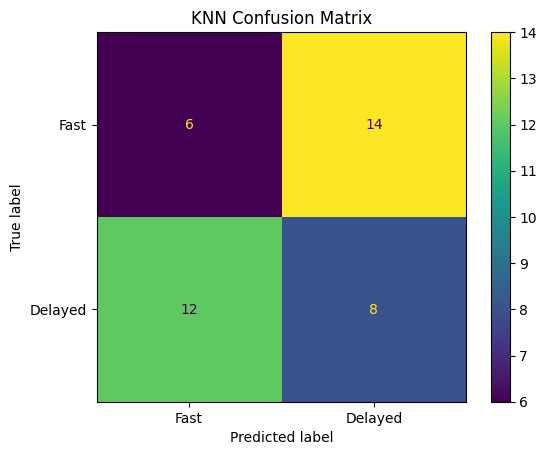

In [ ]:
cm_knn = confusion_matrix(y_test, knn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Fast", "Delayed"]
)

disp.plot()

plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20]
}

print("Parameter grid created!")

Parameter grid created!


In [ ]:
dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best parameters: {'max_depth': 2, 'min_samples_split': 2}
Best CV F1 Score: 0.6170268072355359


In [ ]:
dt_model = grid_search.best_estimator_

print("Decision Tree model created!")
print(dt_model)

Decision Tree model created!
DecisionTreeClassifier(max_depth=2, random_state=42)


In [ ]:
dt_pred = dt_model.predict(X_test_scaled)

print("Decision Tree predictions:")
print(dt_pred[:20])

Decision Tree predictions:
[1 0 1 0 1 1 0 1 0 0 1 1 0 0 1 1 1 1 0 1]


In [ ]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Results")
print("------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Results
------------------------
Accuracy : 0.5
Precision: 0.5
Recall   : 0.7
F1 Score : 0.5833333333333334


In [ ]:
print(classification_report(
    y_test,
    dt_pred,
    target_names=["Fast", "Delayed"]
))

              precision    recall  f1-score   support

        Fast       0.50      0.30      0.38        20
     Delayed       0.50      0.70      0.58        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.48        40
weighted avg       0.50      0.50      0.48        40



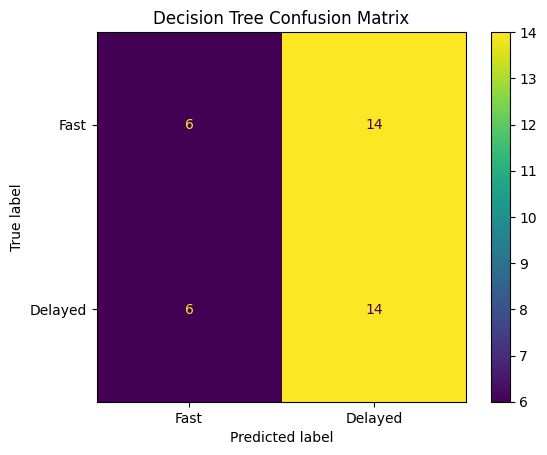

In [ ]:
cm_dt = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Fast", "Delayed"]
)

disp.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

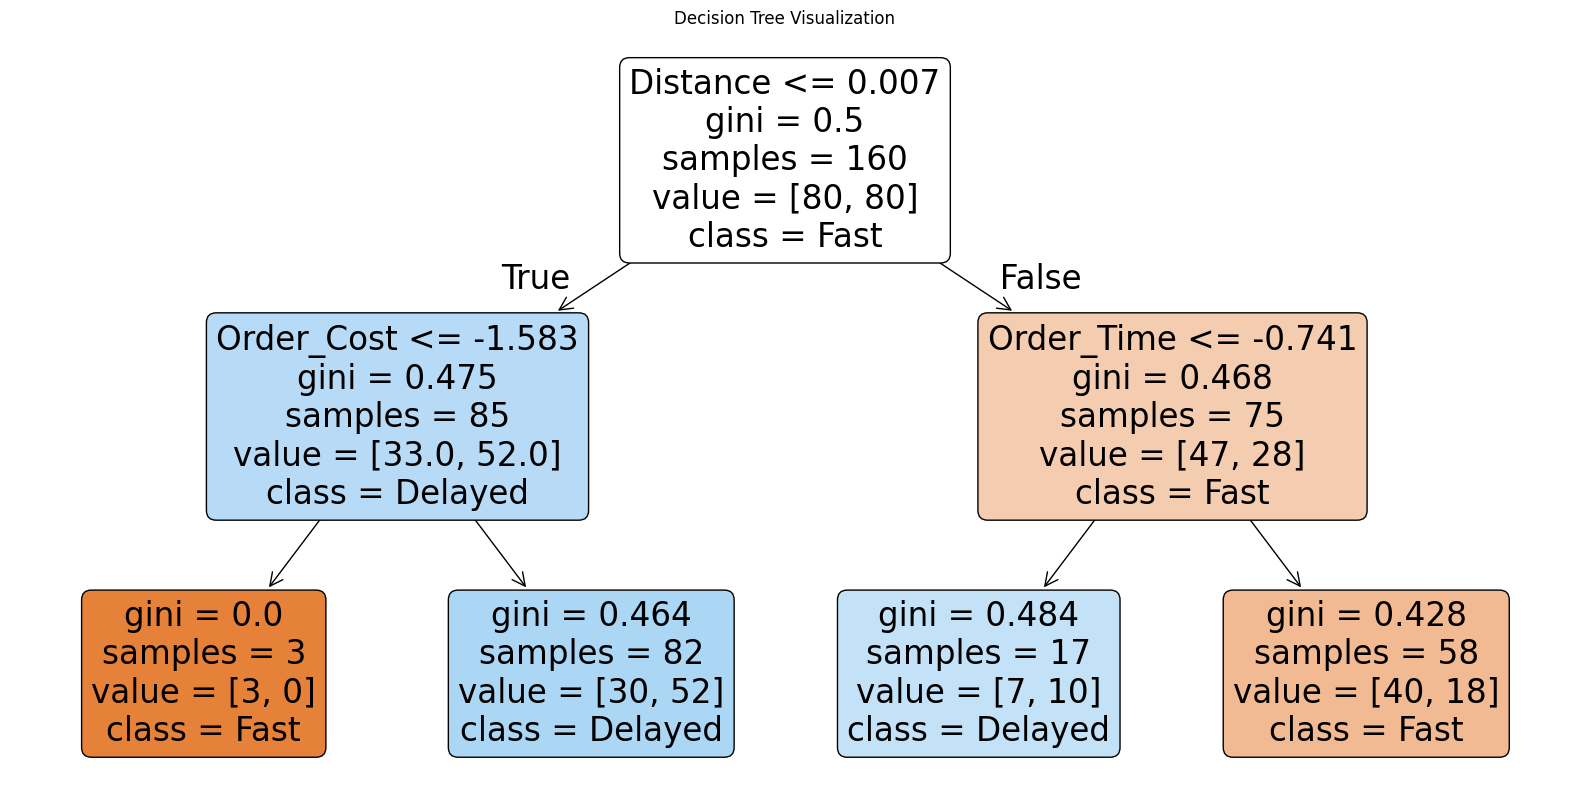

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=features,
    class_names=["Fast", "Delayed"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "KNN",
        "Decision Tree"
    ],

    "Accuracy": [
        nb_accuracy,
        knn_accuracy,
        dt_accuracy
    ],

    "Precision": [
        nb_precision,
        knn_precision,
        dt_precision
    ],

    "Recall": [
        nb_recall,
        knn_recall,
        dt_recall
    ],

    "F1 Score": [
        nb_f1,
        knn_f1,
        dt_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.40,0.400000,0.4,0.400000
1,KNN,0.35,0.363636,0.4,0.380952
2,Decision Tree,0.50,0.500000,0.7,0.583333


In [ ]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.40,0.4000,0.4,0.4000
1,KNN,0.35,0.3636,0.4,0.3810
2,Decision Tree,0.50,0.5000,0.7,0.5833


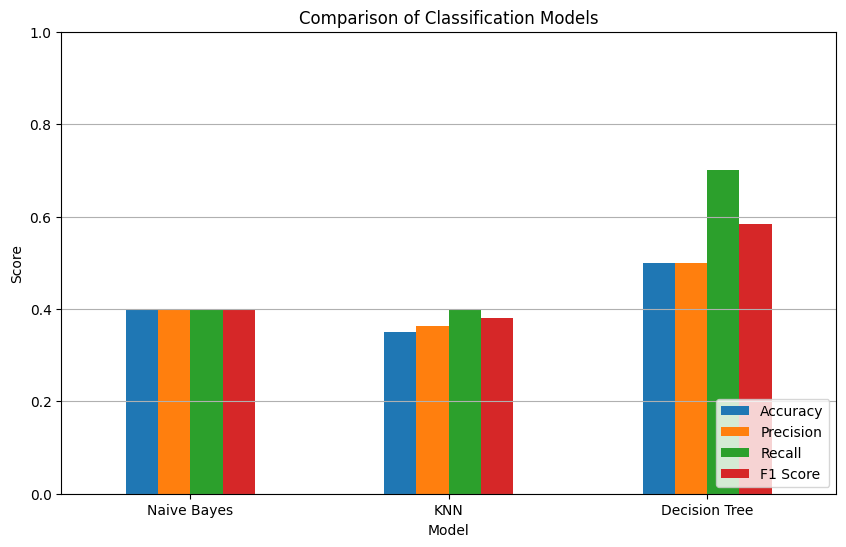

In [ ]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")

plt.show()

In [ ]:
print("MODEL COMPARISON")
print("=" * 50)

for _, row in results.iterrows():
    print(
        f"{row['Model']}: "
        f"Accuracy={row['Accuracy']:.4f}, "
        f"Precision={row['Precision']:.4f}, "
        f"Recall={row['Recall']:.4f}, "
        f"F1={row['F1 Score']:.4f}"
    )

MODEL COMPARISON
Naive Bayes: Accuracy=0.4000, Precision=0.4000, Recall=0.4000, F1=0.4000
KNN: Accuracy=0.3500, Precision=0.3636, Recall=0.4000, F1=0.3810
Decision Tree: Accuracy=0.5000, Precision=0.5000, Recall=0.7000, F1=0.5833


In [ ]:
nb_prob = nb_model.predict_proba(X_test_scaled)[:, 1]
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]
dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]

print("Prediction probabilities generated successfully!")

Prediction probabilities generated successfully!


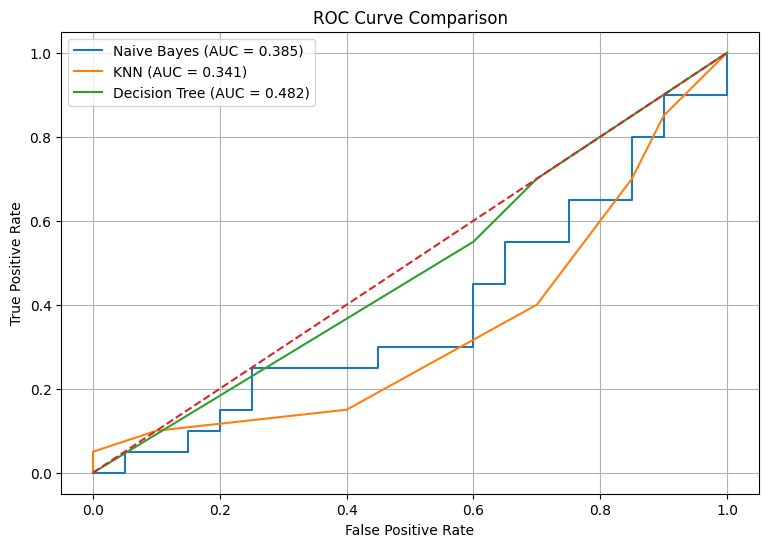

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

auc_nb = roc_auc_score(y_test, nb_prob)
auc_knn = roc_auc_score(y_test, knn_prob)
auc_dt = roc_auc_score(y_test, dt_prob)

plt.figure(figsize=(9, 6))

plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()

In [ ]:
print("ROC-AUC Scores")
print("----------------------")
print("Naive Bayes  :", round(auc_nb, 4))
print("KNN          :", round(auc_knn, 4))
print("Decision Tree:", round(auc_dt, 4))

ROC-AUC Scores
----------------------
Naive Bayes  : 0.385
KNN          : 0.3413
Decision Tree: 0.4825


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Distance,0.509679
9,Order_Cost,0.261881
5,Order_Time,0.228440
2,Traffic_Conditions,0.000000
1,Weather_Conditions,0.000000
4,Order_Priority,0.000000
3,Delivery_Person_Experience,0.000000
6,Vehicle_Type,0.000000
7,Restaurant_Rating,0.000000
8,Customer_Rating,0.000000


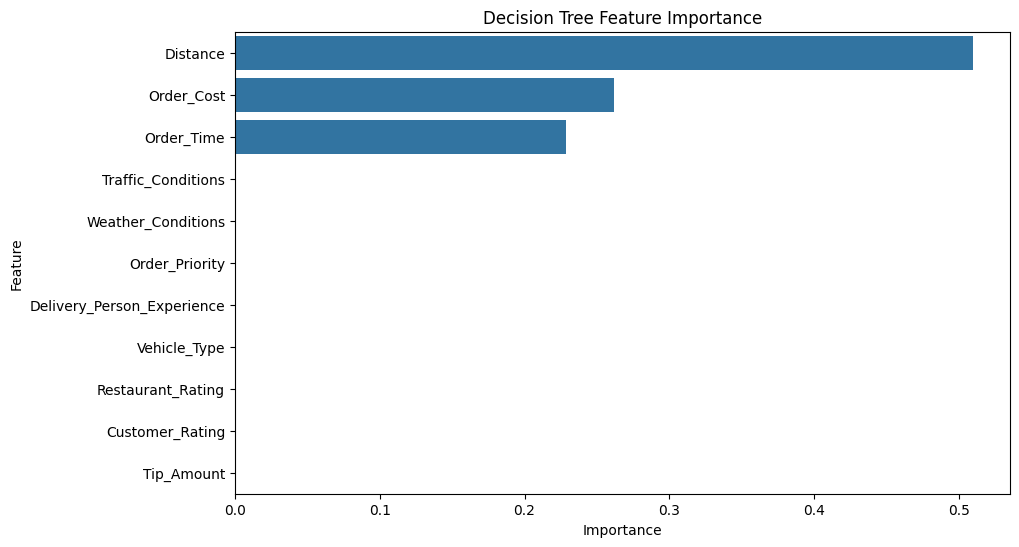

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()


In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        nb_accuracy,
        knn_accuracy,
        dt_accuracy
    ],
    "Precision": [
        nb_precision,
        knn_precision,
        dt_precision
    ],
    "Recall": [
        nb_recall,
        knn_recall,
        dt_recall
    ],
    "F1 Score": [
        nb_f1,
        knn_f1,
        dt_f1
    ],
    "ROC-AUC": [
        auc_nb,
        auc_knn,
        auc_dt
    ]
})

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Naive Bayes,0.40,0.4000,0.4,0.4000,0.3850
1,KNN,0.35,0.3636,0.4,0.3810,0.3413
2,Decision Tree,0.50,0.5000,0.7,0.5833,0.4825


In [ ]:
final_results.round(4).to_csv(
    "Food_Delivery_Model_Comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [ ]:
print("FOOD DELIVERY TIME PREDICTION - KEY INSIGHTS")
print("=" * 55)

print("\n1. The project predicts whether a food delivery will be Fast or Delayed.")

print("\n2. Three classification models were evaluated:")
print("   - Gaussian Naive Bayes")
print("   - K-Nearest Neighbors (KNN)")
print("   - Decision Tree")

print("\n3. The models were evaluated using:")
print("   - Accuracy")
print("   - Precision")
print("   - Recall")
print("   - F1 Score")
print("   - ROC-AUC")

print("\n4. The Decision Tree feature importance shows which delivery")
print("   factors contributed most to the predictions.")

FOOD DELIVERY TIME PREDICTION - KEY INSIGHTS

1. The project predicts whether a food delivery will be Fast or Delayed.

2. Three classification models were evaluated:
   - Gaussian Naive Bayes
   - K-Nearest Neighbors (KNN)
   - Decision Tree

3. The models were evaluated using:
   - Accuracy
   - Precision
   - Recall
   - F1 Score
   - ROC-AUC

4. The Decision Tree feature importance shows which delivery
   factors contributed most to the predictions.
